In [1]:
import sys  
import numpy as np
sys.path.insert(1, '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/')

import matplotlib.pyplot as plt


from src import BoidSimulator ,BoidVisualizer ,PropertyAnalysis ,SimSaverLoader ,SimParams ,KernelReadout, FlatReadout

%load_ext autoreload
%autoreload 2

# Fig 1

## a
the x-coordinate of the Lorenz system 0.5 units in the future (black). The prediction by the particle position based reservoir is shown in red.

In [ ]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/donut'
data = SimSaverLoader.find_npzs(run_path)

In [ ]:
visualiser = BoidVisualizer([data[0]])
visualiser.get_frames(max_columns=5, frame_indexes=range(900,1000,10),trails=10)
plt.show()

## b
Consistency profile of the reservoir truncated to the largest 100 components
$\Theta$

In [ ]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/super_long'
datas = SimSaverLoader.find_npzs(run_path)
fr = FlatReadout(datas[0],datas[1])

v1= fr.get_reservoir_state_vectorised(datas[0])
v2= fr.get_reservoir_state_vectorised(datas[1])

pa = PropertyAnalysis([v1,v2])


In [ ]:
print(pa.calc_consistency_profile(pa.sv_norm[0],pa.sv_norm[1]))

ccx = pa.calc_consistency_profile(pa.sv_norm[0],pa.sv_norm[1])
ax = pa.plot_consistency_profile(ccx)
plt.show()

# Fig 2

In [ ]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/super_long'
datas = SimSaverLoader.find_npzs(run_path)
fr = FlatReadout(datas[0],datas[1])
v1 = fr.get_reservoir_state_vectorised(datas[0])
v2 = fr.get_reservoir_state_vectorised(datas[1])

prediction, corr_coef = fr.ridge_prediction(v1,v2)

pa = PropertyAnalysis([v1,v2])

In [ ]:
pa.plot_consistency_profile((0,1),dpi=100)


In [ ]:
plot = fr.get_plot(prediction,corr_coef,[2000,4000])
plot.set_ybound(-7,7)
plt.show()


# Fig 5

In [2]:
%reload_ext autoreload
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/lymurn_params'
datas = SimSaverLoader.find_npzs(run_path)
kr = KernelReadout(200,datas[0],datas[1],washout=1000)

sv1 = kr.get_reservoir_state_vectorised(kr.replica1)
sv2 = kr.get_reservoir_state_vectorised(kr.replica2)


Loaded 2 run(s)


Serial Chunks: 100%|██████████| 49/49 [00:34<00:00,  1.41it/s]


In [ ]:
# largest item in the covariance matrix
#5.770892670733141e-06

# avg of the main diagonal
np.mean(np.diag(np.cov(X1o.T,bias=True)))#0.9999793684470543 

# smallest value in the main diagonal
np.min(np.diag(np.cov(X1o.T,bias=True))) -> 0.9999695485903152

In [ ]:
cc, g2=kr.calc_consistency_profile_v1(sv1,sv2)


0.9999695485903152


AssertionError: 

<Axes: xlabel='$k$', ylabel='$\\gamma^{2}_{k}$'>

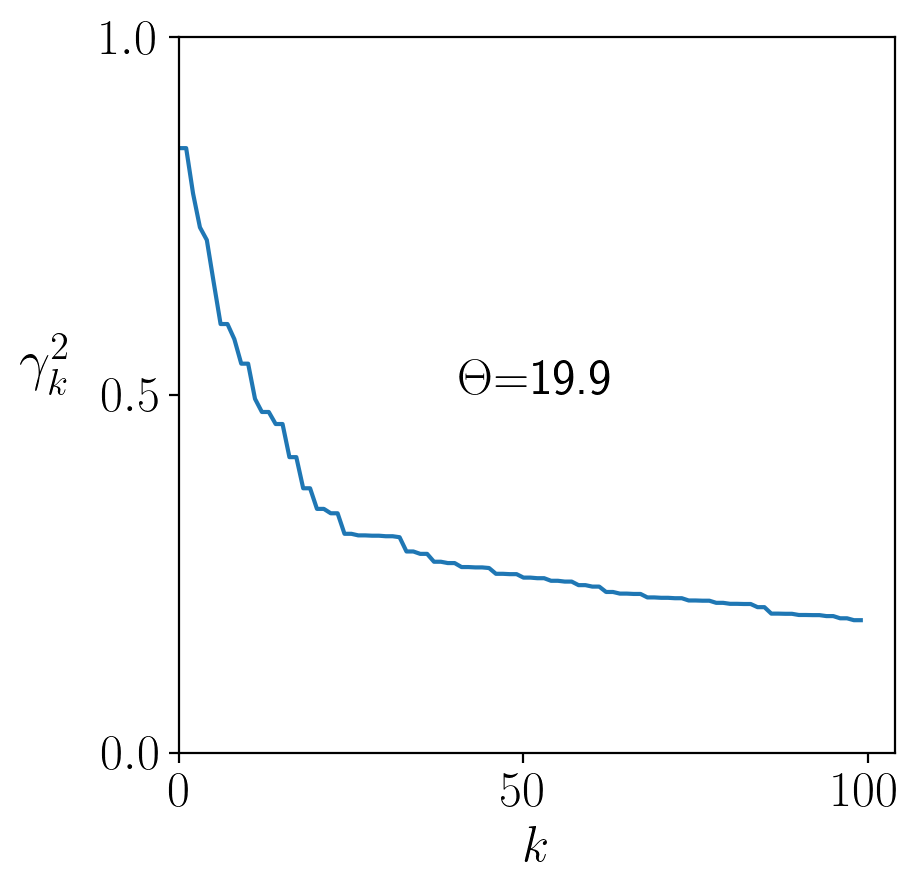

In [15]:
kr.plot_consistency_profile(cc,g2,truncated_to=100)

In [ ]:
prediction,corr_coef = kr.ridge_prediction(sv2,prediction_distance=8)

plot = kr.get_plot(prediction,corr_coef,[0,2000])
plot.set_ybound(-7,7)
plt.show()